<a href="https://colab.research.google.com/github/heisenberg304/Housing-Prices-prediction/blob/develop/analisis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
%%writefile data_housing.py

import pandas as pd
data = pd.read_csv("/content/drive/MyDrive/data_csv/Housing.csv")

FEATURES = ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus']

def encoding(data):
  data = pd.get_dummies(data, columns=["mainroad"])
  data = pd.get_dummies(data, columns=["guestroom"])
  data = pd.get_dummies(data, columns=["basement"])
  data = pd.get_dummies(data, columns=["hotwaterheating"])
  data = pd.get_dummies(data, columns=["airconditioning"])
  data = pd.get_dummies(data, columns=["prefarea"])
  data = pd.get_dummies(data, columns=["furnishingstatus"])
  return data
data_encoding = encoding(data)

Writing data_housing.py


In [ ]:
from data_housing import data

#revisar si hay valores faltantes con:
data.isnull().sum().sort_values()
#despues de usar esto, revise detenidamente y no encontre valores faltantes

#revisar informacion
data.info()
#veo cuales son objetos y cuales son valores numericos

#analizar deesviacion estandar, media y mediana
data.describe()
#identificar que features tienen extremos tanto arriba como abajo

#analizar como se dividen los valores categoricos nominales binarios
#mainroad
#guestroom
#basement
#hotwaterheating
#airconditioning
#prefarea
#furnishingstatus
data["mainroad"].value_counts() #probe a cada categotico


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


,count
mainroad,
yes,468
no,77


#Analizando mean y median de features

-Valores Extremos superiores:
Price,
Area

LLegue a esta conclusion dado que en estos features mean > median, y esto significa que existen valores mucho mas alto de lo comun lo que hace que el promedio aumente y surja la asimetria.

---
-Valores Extremos inferiores:
Stories (numerico discreto)

LLegue a esta conclusion dado que en estos features median > mean, y esto significa que existen valores mucho mas bajo de lo normal lo que hace que el promedio disminuya y surja la asimetria.

---
-No hay valores extremos notables:
Bedrooms,
Bathrooms
LLegue a esta conclusion ya que mean es bastante igual a median, no hay una simetria relevante.

#Clasificacion de features
##Numericos:
price

area

bedrooms (discreto)

bathrooms (discreto)

stories (discreto)

parking (discreto)

##Categoricos:
furnishingstatus: semi-furnished = 227;
unfurnished = 178;
furnished = 140


###Categórica nominal binaria:
mainroad: yes = 468; no = 77

guestroom: yes = 97; no = 448

basement: yes = 191; no = 354

hotwaterheating: yes = 25; no = 520

airconditioning: yes = 172; no = 373

prefarea: yes = 128; no = 417



In [ ]:
from data_housing import data
import matplotlib.pyplot as plt
import numpy as np

price = data["price"]
plt.hist(np.log1p(price)) #np.expm1(price) para descomprimir
plt.ylabel("cantidad de casas")
plt.xlabel("Precio log")
plt.show()

area = data["area"]
plt.hist(np.log1p(area))
plt.ylabel("cantidad de casas")
plt.xlabel("Area log")
plt.show()

#numericas discretas:

plt.hist(data["bedrooms"])
plt.ylabel("cantidad de casas")
plt.xlabel("Bedrooms")
plt.show()

plt.hist(data["bathrooms"])
plt.ylabel("cantidad de casas")
plt.xlabel("Bathrooms")
plt.show()

plt.hist(data["stories"])
plt.ylabel("cantidad de casas")
plt.xlabel("Stories")
plt.show()

plt.hist(data["parking"])
plt.ylabel("cantidad de casas")
plt.xlabel("Parking")
plt.show()

#DISTRIBUCIONES DE FEATURES NUMERICOS:

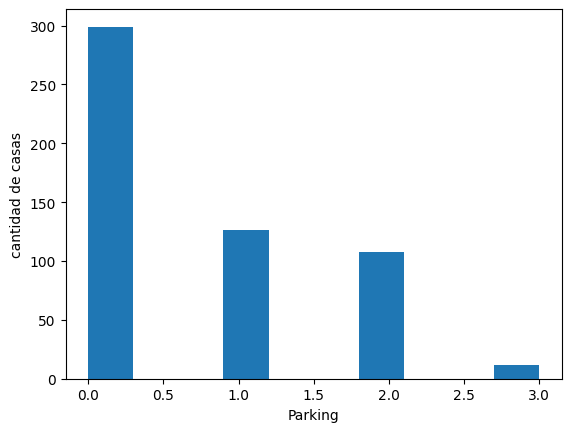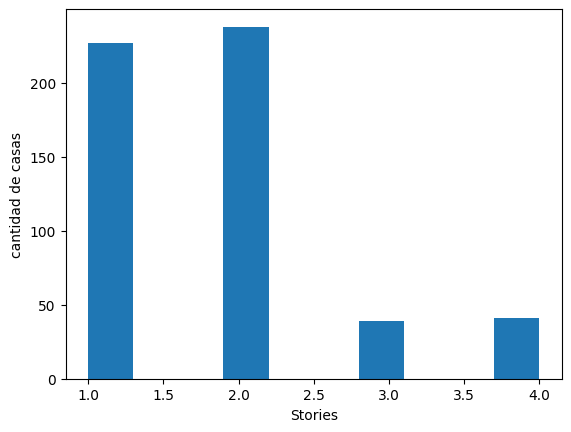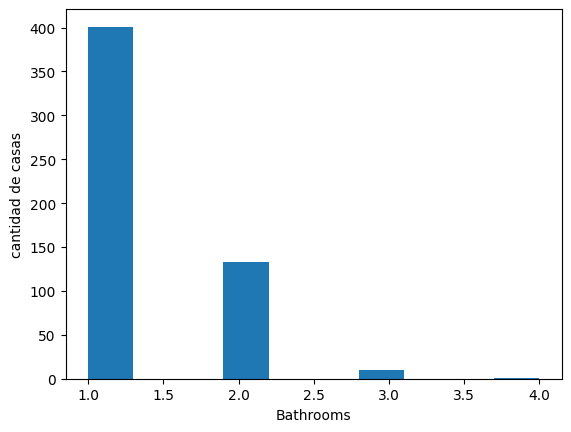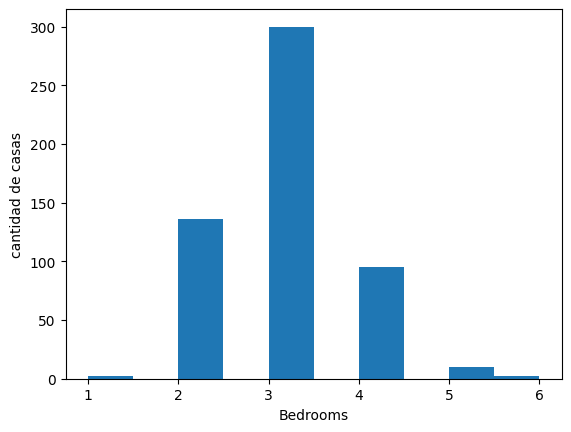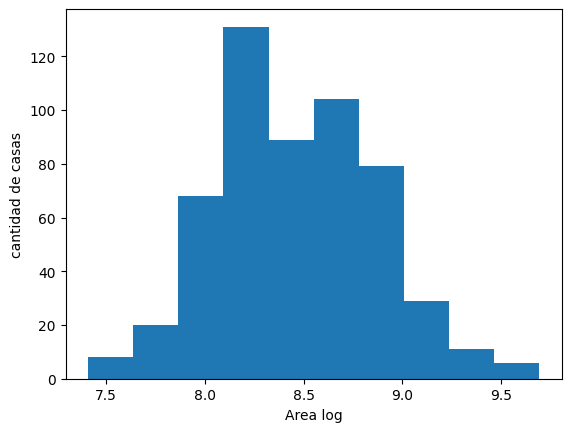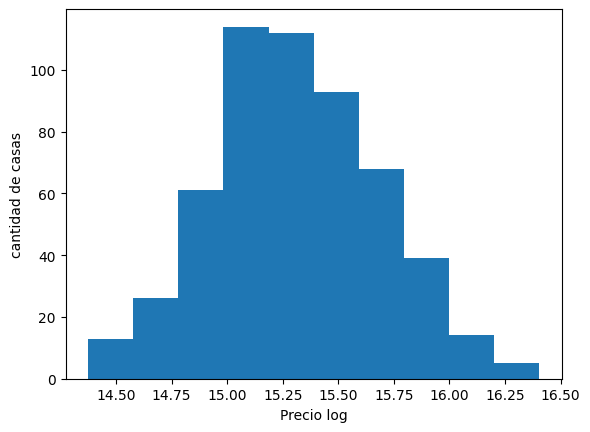

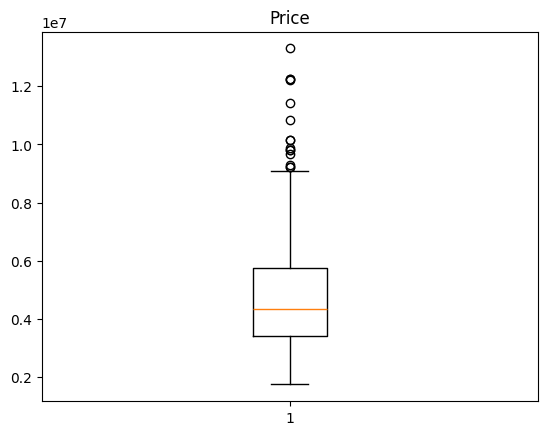

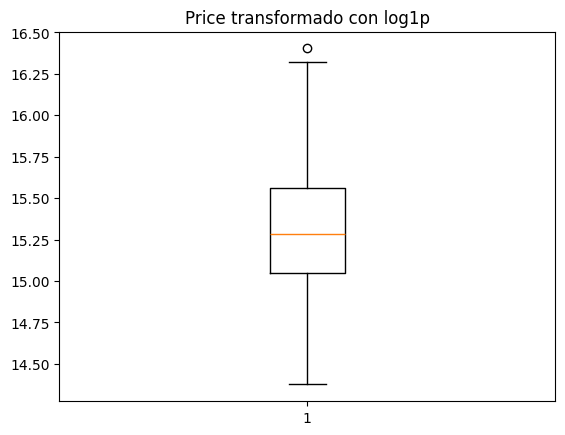

In [ ]:
from data_housing import data
import matplotlib.pyplot as plt
import numpy as np

price = data["price"]
plt.boxplot(price)
plt.title("Price")
plt.show()

plt.boxplot(np.log1p(price))
plt.title("Price transformado con log1p")
plt.show()

#Analisis de la distribucion de las variables categoricas

##Price
La variable Price presenta una distribución con asimetría positiva, donde la mayoría de observaciones se concentra en valores relativamente bajos y medios, mientras que existen varios valores extremos superiores.

La mediana parece representar mejor el centro de los datos que el promedio, ya que los valores extremos desplazan la media hacia arriba.

Esto confirma la hipótesis inicial de que existen propiedades con precios excepcionalmente altos.

---
##Area

La variable Area presenta un comportamiento similar al de Price, con una concentración de observaciones en valores menores y una cola hacia valores altos.

También muestra valores extremos superiores.

Esto sugiere una posible relación positiva entre Area y Price, aunque todavía debe verificarse visualmente mediante un gráfico de dispersión (scatter plot).

---

###Transformación aplicada

Se aplicó una transformación:

```log1p()```

sobre las variables analizadas para reducir la asimetría y disminuir el efecto de valores extremos.

Después de la transformación, las distribuciones se observaron:

* más compactas
* más equilibradas
* con menor dispersión extrema
* más adecuadas para etapas posteriores de modelado

La transformación redujo significativamente los valores extremos, aunque algunos continúan presentes.

---

##Bedrooms:


##Bathrooms:


##Stories:


##Parking:



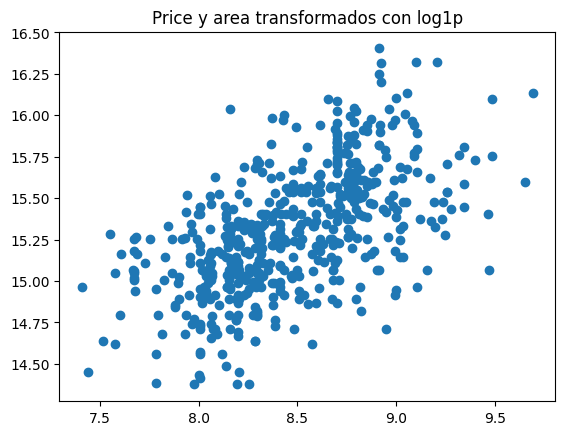

In [2]:
from data_housing import data
import matplotlib.pyplot as plt
import numpy as np

price = np.log1p(data["price"])
area = np.log1p(data["area"])
plt.scatter(area, price)
plt.title("Price y area transformados con log1p")
plt.show()

si

In [ ]:
from data_housing import data_encoding
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


corr = data_encoding.corr()
sns.heatmap(corr)
plt.title("correalaciones")
plt.show()




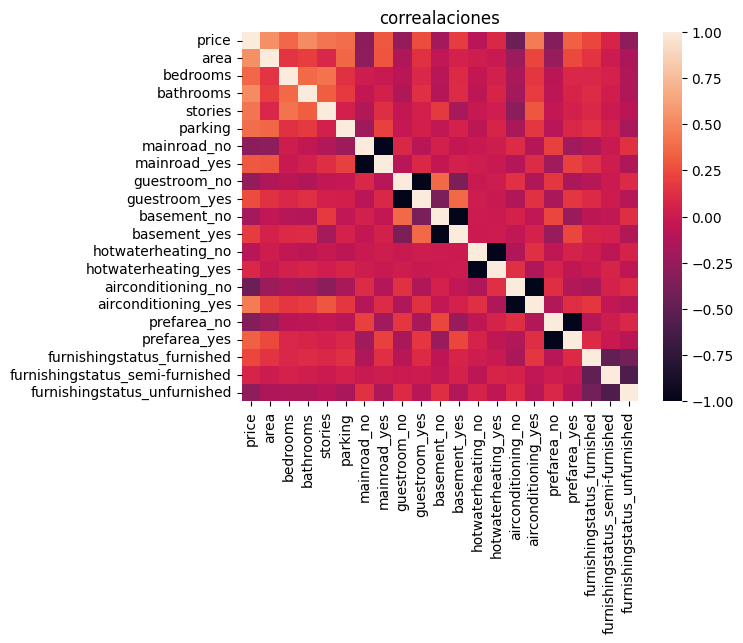

In [8]:
from data_housing import data_encoding, FEATURES

target_corr = (data_encoding.corr(numeric_only=True)['price'].sort_values(ascending=False))
display(target_corr)

data.columns

ImportError: cannot import name 'FEATURES' from 'data_housing' (/content/data_housing.py)